In [1]:
import joblib
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import logging
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from datetime import datetime
import keras

I0000 00:00:1773189903.665998    4517 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

In [ ]:
#Check GPUs availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("GPU is available")
    print("Physical Devices:", tf.config.list_physical_devices('GPU'))
else:
    print("GPU is NOT available. Check CUDA/cuDNN installation.")

Num GPUs Available:  2
GPU is available
Physical Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
logging.basicConfig(format="%(asctime)s %(name)s %(levelname)s %(message)s")
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)

In [6]:
def read_training_and_testing_set(train_path:str, test_path:str, label_encoder):
    """
    Args:
        train_path:file CSV includes paths of training set
        test_path: file CSV includes paths of training set

    Returns:
        X_train: Paths of training set
        X_test: Paths of testing set
        y_train: labels of training set already transfered to numeric by label_ encoder
        y_test: labels of testing set already transfered to numeric by label_ encoder
    """
    logger.info("Read paths of training and testing set is processing.....\n")

    df_paths_labels_train = pd.read_csv(train_path)
    x_train = (df_paths_labels_train["Paths"]).values
    y_train = (df_paths_labels_train["True labels"]).values


    df_paths_labels_test = pd.read_csv(test_path)
    x_test = (df_paths_labels_test["Paths"]).values
    y_test = (df_paths_labels_test["True labels"]).values

    y_train = label_encoder.transform(y_train)
    y_test = label_encoder.transform(y_test)
    return x_train, x_test, y_train, y_test

In [7]:
def import_one_sample(sample:str, data_set):
    """
    Args:
        sample: 1 sample
        data_set:data of one to 6 samples

    Returns:
        data_test:data_set:data of one to 6 samples
    """
    data = np.loadtxt(
        fname=sample,
        delimiter=","
    )
    data = data.reshape(1, data.shape[0], data.shape[1])
    data_set.append(data)
    return data_set


In [8]:
def import_data_set(X):
    """
    Args:
        X: paths of train data or test data that you want to import

    Returns:
        data: train data or test data that you want to import 
    """
    data_set = []
    for sample in X:
        data_set = import_one_sample(sample, data_set)

    data_set = np.concatenate(data_set, axis=0)
    print("data_set", data_set.shape)
    return data_set

In [9]:
def define_architecture_cnn_model(out_shape):
    """
    Args:
        out_shape: Shape of output of CNN_model

    Returns:
        model : Architecture of CNN model

    """
    model = keras.Sequential(
        [   keras.Input(shape = (3600, 128,1)),
            keras.layers.Conv2D(8, 3, 1, padding='same', activation='relu', name='conv2d_1'),
            keras.layers.MaxPooling2D((3, 1), name='max_pool_1'),

            keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv2d_2'),
            keras.layers.MaxPooling2D((3, 1), name='max_pool_2'),

            keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv2d_4'),
            keras.layers.MaxPooling2D((2, 2), name='max_pool_3'),

            keras.layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv2d_5'),
            keras.layers.MaxPooling2D((2, 2), name='max_pool_4'),

            keras.layers.Conv2D(filters=8, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv2d_6'),
            keras.layers.MaxPooling2D((2, 2), name='max_pool_5'),

            keras.layers.Flatten(name='Flatten_1'),
            keras.layers.Dropout(0.2, seed=42),
            keras.layers.Dense(512, activation="relu"),
            keras.layers.Dropout(0.2, seed=42),
            keras.layers.Dense(out_shape, activation='softmax', name='dense_3')
        ]
    )
    return model

In [10]:
def build_cnn_model(data_train, y_train, data_test, y_test, batch_size, epochs, output_shape):
    """
    Args:
        data_train: The training set that is used to train CNN model
        y_train: The labels of training set that is used to train CNN model
        data_test: The validation set that is used to validate CNN model
        y_test:
        batch_size:
        epochs:
        input_shape: Shape of input of CNN_model
        output_shape: Shape of output of CNN_model

    Returns:
        model: CNN_model after training
    """
    logger.info("Build cnn model is processing.....")

    model = define_architecture_cnn_model(output_shape)
    # checkpointer = save_the_best_epoch()

    # compile model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'], )
    train_model = model.fit(data_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            shuffle=True,
                            validation_data=(data_test, y_test),
                            verbose="auto",
                            )
    model.export("SaveModel_CNN/my_saved_model")
    model.save("SaveModel_CNN/my_saved_model.keras")  # Save as Keras format for feature extraction
    print("built")
    return train_model

In [11]:
def plot_accuracy(history):
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Testing Accuracy')
    plt.title('Training vs Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

2026-03-11 09:48:27,836 root INFO Read paths of training and testing set is processing.....

2026-03-11 09:48:27,879 root INFO Import data of training set is processing....
2026-03-11 09:50:20,933 root INFO Import data of  set is processing....



data_set (926, 3600, 128)


2026-03-11 09:51:09,092 root INFO Build cnn model is processing.....


data_set (397, 3600, 128)


I0000 00:00:1773190269.753306    4517 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:0b:00.0, compute capability: 7.5
I0000 00:00:1773190269.755709    4517 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9055 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:41:00.0, compute capability: 7.5


...

2026-03-11 09:57:35,850 tensorflow INFO Assets written to: SaveModel_CNN/my_saved_model/assets


Saved artifact at 'SaveModel_CNN/my_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3600, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135575099025232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099026576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099026192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099027152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099026000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099028112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099028880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099027344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099028304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135575099028688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

2026-03-11 09:57:35,942 h5py._conv DEBUG Creating converter from 5 to 3
2026-03-11 09:57:36,552 matplotlib.pyplot DEBUG Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-11 09:57:36,556 matplotlib.pyplot DEBUG Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-11 09:57:36,560 matplotlib.font_manager DEBUG findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-03-11 09:57:36,561 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/mnt/d/Dan/D12_TR/joblib_venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-03-11 09:57:36,561 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/mnt/d/Dan/D12_TR/joblib_venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='n

built


2026-03-11 09:57:36,640 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/usr/share/fonts/opentype/mathjax/MathJax_Main-Italic.otf', name='MathJax_Main', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-03-11 09:57:36,641 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/usr/share/fonts/opentype/mathjax/MathJax_Math-BoldItalic.otf', name='MathJax_Math', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-03-11 09:57:36,642 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-BI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-03-11 09:57:36,643 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/usr/share/fonts/opentype/mathjax/MathJax_Fraktur-Bold.otf', name='MathJax_Fraktur', style='normal', variant='normal', weight=700, stretch='normal', si

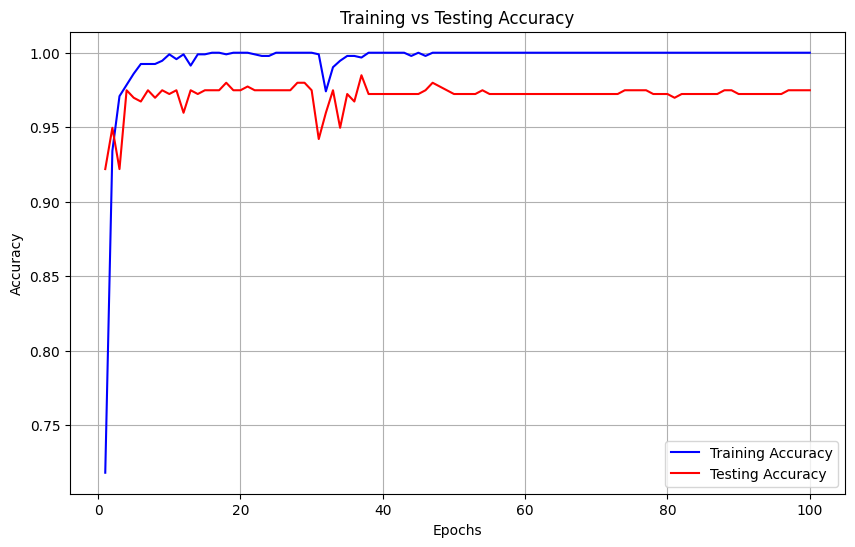

Accuracy at last epoch (100): Training accuracy: 100.0000, val = 0.9748


In [12]:
enc_path   = 'SaveModel_SVM/label_encoder.joblib'
label_encoder = joblib.load(enc_path)


x_train, x_test, y_train, y_test = read_training_and_testing_set("Paths_and_Labels_of_TrainingSet.csv",
                                                                    "Paths_and_Labels_of_TestingSet.csv", label_encoder)



logger.info("Import data of training set is processing....")
data_train = import_data_set(x_train)
logger.info("Import data of  set is processing....\n")
data_test = import_data_set(x_test)
data_train = data_train[..., np.newaxis]
data_test = data_test[..., np.newaxis]
history = build_cnn_model(data_train, y_train, data_test, y_test, batch_size=64, epochs=100, output_shape=6)


# Accuracy testing theo từng epoch
# Accuracy train theo từng epoch
train_acc = history.history['accuracy']

# Accuracy validation theo từng epoch
val_acc = history.history['val_accuracy']
plot_accuracy(history)
# print("Train acc từng epoch:", train_acc)
# print("Val acc từng epoch:", val_acc)
last_epoch = len(history.history['accuracy'])
last_train_acc = history.history['accuracy'][-1]
last_val_acc = history.history['val_accuracy'][-1]
print(f"Accuracy at last epoch ({last_epoch}): Training accuracy: {last_train_acc*100:.4f}, val = {last_val_acc:.4f}")